In [2]:
print("all ok")

all ok


In [3]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [4]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [5]:
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is not set in the environment variables.")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [6]:
from langchain_openai import ChatOpenAI

In [7]:
chat_llm = ChatOpenAI(model = "gpt-4o-mini")

In [8]:
chat_llm.invoke("Hello, how are you?").content

"Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

In [9]:
from typing_extensions import Annotated, TypedDict
import operator
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage

In [10]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [11]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response"""
    response = chat_llm.invoke(state["messages"]) # AIMessage
    return {
        "messages": [response]
    }

In [12]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message"""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the genearted answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [13]:
from langgraph.graph import StateGraph

In [14]:
builder = StateGraph(GraphState)

In [15]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [16]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [17]:
app = builder.compile()

In [18]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(idGraph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [19]:
from IPython.display import Image, display

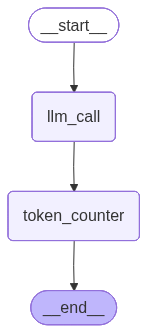

In [20]:
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
result = app.invoke({
    "messages": [HumanMessage(content="What is the capital of France?")]
})

In [22]:
result

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='The capital of France is Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6331672635', 'id': 'chatcmpl-DHaRiAFLBTIBZa2uYbvShw3HVoVux', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd40b-701e-7483-b723-0544055290b6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'rea

In [23]:
for m in result["messages"]:
    print(f"{m.__class__.__name__}: {m.content}\n")

HumanMessage: What is the capital of France?

AIMessage: The capital of France is Paris.

AIMessage: Total token number in the genearted answer (word count) is 6



In [24]:
chat_llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002347A1D3F20>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000023478AF3140>, root_client=<openai.OpenAI object at 0x000002347A32A780>, root_async_client=<openai.AsyncOpenAI object at 0x000002347A8DAF30>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [29]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [31]:
api_wrapper = WikipediaAPIWrapper(top_k_results = 5, doc_content_chars_max= 500)

In [32]:
wiki_tool = WikipediaQueryRun(api_wrapper= api_wrapper)

In [33]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [43]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

In [51]:
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
TAVILY_API_KEY = "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"
TAVILY_API_KEY

'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'

In [52]:
tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [53]:
tool.invoke({"query":"How is the job market for fresh graduates in 2026?"})

[{'title': 'The 2026 Job Market: Supporting Students and Closing the Skills Gap',
  'url': 'https://findingequilibriumfuturehighered.substack.com/p/the-2026-job-market-supporting-students',
  'content': "#### What About the Spring of 2026?\n\nLooking forward, the National Association of Colleges and Employers (NACE) conducts semi-annual surveys of employer hiring intentions. The story told in the most recent study is aligned with the above discussion of the general employment situation. The November 2025 data show that 45% of the employers surveyed describe the job market as ‘fair’ – the worst characterization of the job market for new college graduates we have seen since 20-21.\n\nSource: NACE. [...] # Finding Equilibrium: Two Economists on Higher Ed's Future\n\n# The 2026 Job Market: Supporting Students and Closing the Skills Gap\n\n### Ideas for Preparing More Career-Ready Graduates\n\nJay Akridge and David Hummels\n\nDec 19, 2025\n\nWe’ve written a couple of times this fall on the 

In [54]:
from langchain_community.tools import DuckDuckGoSearchRun

In [60]:
search=DuckDuckGoSearchRun()

In [62]:
search.invoke("What is the latest update on iphone17 release?")

"iPhone17releasedate. New iPhone models for 2025 were unveiled on Tuesday, September 9, 2025. Pre-orders started on Friday, September 12, 2025, with orders to start being delivered on September 19, 2025. iPhone17Pro. Exceptional performance. New Center Stage front camera. Ultimate pro camera system. Breakthrough battery life. A19 Pro chip. TheiPhone17wasreleasedin September 2025, which means now is a good time to buy. A new model is not expected until early 2027, because Apple is changing its entry-level iPhone timing. Here's when we expect theiPhone17to arrive and go on sale — according to rumors and precedent.Stayupdatedonthelatestreleasesand our top recommendations across your favorite streaming platforms. Apple said itsiPhone17will start at $799—the same price it launched its iPhone 16 at—with the Air at $999, the Pro at $1,099, and Pro Max at $1,199. Pre-orders for theiPhone17line open Friday, with availability starting next Friday, Sept."

In [63]:
# other inbuilt tools : bingsearch, googleserperapi